In [1]:
from typing import TypedDict
from typing import Annotated

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [61]:
from langchain_openai import ChatOpenAI
#llm = ChatOpenAI(model="gpt-4-turbo-preview")
llm = ChatOpenAI(model="gpt-4.1-mini")

In [62]:
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7ef149ebcf20>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7ef149f9aed0>, root_client=<openai.OpenAI object at 0x7ef149fa4290>, root_async_client=<openai.AsyncOpenAI object at 0x7ef149ebed80>, model_name='gpt-4.1-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [ ]:
#from langchain.chat_models import init_chat_model


/home/anjucv/.cache/pypoetry/virtualenvs/rag-task1-_QzYQtjV-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#llm = init_chat_model("google_genai:gemini-2.5-flash")

In [63]:
llm.invoke("who is the first person to walk in to moon?")

AIMessage(content="The first person to walk on the Moon was Neil Armstrong. He did so on July 20, 1969, during NASA's Apollo 11 mission.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 18, 'total_tokens': 50, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_53108d00e8', 'id': 'chatcmpl-DKeUooo8Z8GVkguM0L7xyI7JJWhd5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cff96-c222-7a01-828f-17075fae6fbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 32, 'total_tokens': 50, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

# section 2

# ########################################################################

In [6]:
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages

In [7]:
class State(TypedDict):
    message:Annotated[list,add_messages]

def chatbot(state:State) ->State:
    return {"message": [llm.invoke(state["message"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node",chatbot)

builder.add_edge(START,"chatbot_node")
builder.add_edge("chatbot_node",END)

graph = builder.compile()

    

In [8]:
message = {"role":"user","content":"who walked on the moon for the first time? Print only the name"}
response = graph.invoke({"message":[message]})
response

{'message': [HumanMessage(content='who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='801dfed0-f0fc-4d79-b2dc-dd9e939d10c4'),
  AIMessage(content='Neil Armstrong', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 21, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0125-preview', 'system_fingerprint': None, 'id': 'chatcmpl-DKc9ghmsRG0Rjeg6UYZEYAbszahxY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cff0d-7be1-71e3-81bb-8840a26f15a0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 2, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0},

In [9]:
from langchain_core.messages import HumanMessage
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit","exit"}:
        break
    if not in_message:
        print("Please enter a message.")
        continue
    
    if state is None:
        state = {"message": [HumanMessage(content=in_message)]}
    else:
        state["message"].append(HumanMessage(content=in_message))
    
    state = graph.invoke(state)
    print("Bot:",state["message"][-1].content)

Bot: Neil Armstrong


# section 3 add tools

In [52]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition

In [ ]:
# created a tool function to use as tool

In [12]:
@tool
def get_stock_price(symbol: str) -> float:
    """Return the current price of a stock given the stock symbol.

    :param symbol: stock symbol
    :return: current price of the stock
    """
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RTL": 87.6,
    }.get(symbol, 0.0)

tools = [get_stock_price]
#init_chat_model("google_genai:gemini-2.5-flash")
llm_with_tools = llm.bind_tools(tools)

In [13]:
from langgraph.graph import MessagesState

class State(MessagesState):
    pass

def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

graph = builder.compile()

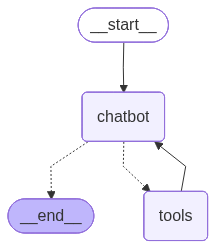

In [14]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
from langchain_core.messages import HumanMessage
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit","exit"}:
        break
    if not in_message:
        print("Please enter a message.")
        continue
    
    if state is None:
        state = {"messages": [HumanMessage(content=in_message)]}
    else:
        state["messages"].append(HumanMessage(content=in_message))
    
    state = graph.invoke(state)
    print("Bot:",state["messages"][-1].content)

Bot: The total price of AMZN and RTL stocks combined is $237.60.


# section 4 add memory

In [16]:
from langgraph.checkpoint.memory import MemorySaver

In [17]:
memory = MemorySaver()

In [18]:
from langgraph.graph import MessagesState

class State(MessagesState):
    pass

def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

graph = builder.compile(checkpointer=memory)

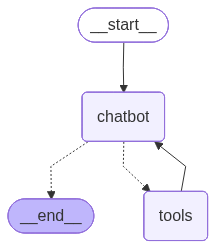

In [19]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
config = {'configurable': {'thread_id':'1'}}

from langchain_core.messages import HumanMessage
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit","exit"}:
        break
    if not in_message:
        print("Please enter a message.")
        continue
    
    if state is None:
        state = {"messages": [HumanMessage(content=in_message)]}
    else:
        state["messages"].append(HumanMessage(content=in_message))
    
    state = graph.invoke(state,config=config)
    print("Bot:",state["messages"][-1].content)

Bot: The current stock price of AMZN (Amazon.com Inc) is $150.00.
Bot: The current stock prices are as follows:

- **Amazon.com Inc (AMZN):** $150.00
- **Microsoft Corporation (MSFT):** $200.30
Bot: As of my last update in December 2023, the President of India is Droupadi Murmu. She made history by becoming the first person from India's tribal community to be elected as President. Please note that specific tenure details or real-time updates may vary, so it's advisable to check the latest news for the most current information.


# section 5 add multiple tool , Human in loop , memory

In [1]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4.1-mini")

/home/anjucv/.cache/pypoetry/virtualenvs/rag-task1-_QzYQtjV-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from typing import TypedDict,Annotated

from langgraph.checkpoint.memory import MemorySaver
memory= MemorySaver()


from langgraph.types import interrupt,Command

In [4]:
@tool
def get_stock_price(symbol: str) -> float:
    """Return the current price of a stock given the stock symbol.

    :param symbol: stock symbol
    :return: current price of the stock
    """
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RTL": 87.6,
    }.get(symbol, 0.0)

@tool
def buy_stocks(symbol:str,quantity:int,total_price:float)->str:
    """purchase stocks given the stock symbol and quantity
      :param symbol: stock symbol
      :param quantity : stock quantity

    """
    decision = interrupt(f"Approve buying {quantity} shares of {symbol}? (yes/no)")
    if isinstance(decision,str) and decision.lower() == "yes":
        return f"""you bought {quantity} shares of {symbol} with {total_price}"""
    
    else:
        return "Permission denied"
    
tools = [get_stock_price,buy_stocks]
#init_chat_model("google_genai:gemini-2.5-flash")
llm_with_tools = llm.bind_tools(tools)

In [5]:
# state
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [6]:
# graph node

def chat_node(state:ChatState):
    """LLM node that may answer or request a tool call
    """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages":[response]}

tool_node = ToolNode(tools)




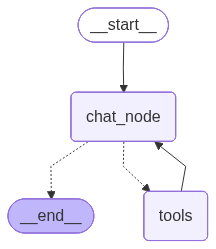

In [19]:
# graph structure 


graph = StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile(checkpointer=memory)
chatbot



In [ ]:

result = chatbot.invoke({"messages":[HumanMessage(content="Buy 5 AMZN stokes")]})
print(result["messages"][-1].content)

You have successfully bought 5 shares of AMZN at a total price of $750.


In [ ]:
config = {'configurable': {'thread_id':'1'}}

state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit","exit"}:
        break
    if not in_message:
        print("Please enter a message.")
        continue
    
    if state is None:
        state = {"messages": [HumanMessage(content=in_message)]}
    else:
        state["messages"].append(HumanMessage(content=in_message))    
    state = chatbot.invoke(state,config=config)
    print("User:",state["messages"][-2].content)
    print("Bot:",state["messages"][-1].content)

User: what is theprice of AMZN stock ?
Bot: The current price of AMZN (Amazon) stock is $150.00.
User: what is theprice of AMZN stock ?
Bot: The price of RTI stock is currently $0.00, and the price of AMZN stock is $150.00. Adding them together, the total is $150.00.
User: what is theprice of AMZN stock ?
Bot: Droupadi Murmu


In [ ]:
# human in loop added

In [20]:
config = {'configurable': {'thread_id':'1'}}

while True:
    in_message = input("You: ")
    print(in_message)
    if in_message.lower() in {"quit","exit"}:
        break
    if not in_message:
        print("Please enter a message.")
        continue

    state = {"messages":[HumanMessage(content=in_message)]}

    result = chatbot.invoke(state,config=config)

    interrupts = result.get("__interrupt__",[])

    if interrupts:
        prompt_to_human = interrupts[0].value
        print(f"human_in_loop:{prompt_to_human}")

        decision = input("your decision: ").strip().lower()

        result = chatbot.invoke(
            Command(resume=decision),
            config=config
        )

    #print("User:",result["messages"][-4].content)
    print("Bot:",result["messages"][-1].content)

What is the stock price of AMZN?
Bot: The current stock price of AMZN is $150.00.
Purchase 10 stocks
human_in_loop:Approve buying 10 shares of AMZN? (yes/no)
Bot: I have purchased 10 shares of AMZN for a total price of $1500.
who is the president of india . give only name
Bot: Droupadi Murmu
which stock i purchased before?
Bot: You purchased 10 shares of the AMZN stock before.
exit
